**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints of 1 fluorophore](#toc1_)    
  - [CDF Fitting procedure](#toc1_1_)    
  - [Reading and fitting data](#toc1_2_)    
    - [Bleaching rate data](#toc1_2_1_)    
    - [ON to OFF data](#toc1_2_2_)    
    - [OFF to ON data](#toc1_2_3_)    
  - [Figure](#toc1_3_)    
    - [Preparation](#toc1_3_1_)    
    - [Figure](#toc1_3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints of 1 fluorophore](#toc0_)

In [ ]:
import glob
import numpy as np
import pandas as pd
from lmfit import Model, Parameters

import fluopy.blinking as bl
import fluopy.distributions as dist
import fluopy.emissions as em
import fluopy.figure as fi

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

reading_from = r"D:\python_output\Chapter_I\0_3_single_f_PFA"

fluopy.blinking version: 0.1.0
fluopy.distributions version: 0.1.0
fluopy.emissions version: 0.1.0
fluopy.figure version: 0.1.0


## <a id='toc1_1_'></a>[CDF Fitting procedure](#toc0_)

In [2]:
def fit_two_expon_mixture(data):
    x = np.linspace(0, 300, 300001)
    model = Model(dist.two_expon_mixture_cdf)
    params = Parameters()
    params.add("p", value=0.5, min=0, max=1)
    params.add("lambda1", value=1, min=0)
    params.add("lambda2", value=0.5, min=0)
    result = model.fit(data, params, x=x)
    parameters = [param.value for param in result.params.values()]

    return parameters

## <a id='toc1_2_'></a>[Reading and fitting data](#toc0_)

### <a id='toc1_2_1_'></a>[Bleaching rate data](#toc0_)

In [3]:
identifiers = ["1e1", "1e2", "1e3", "1e4"]
fingerprints_all_A = []
total_photons_A = []
parameters_all_fit_cdf_A = []
folder_path = reading_from + r"\bl_rate"
for i, id in enumerate(identifiers):
    fingerprints_all_A.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    total_photons_A.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            fingerprints_all_A[i] += pd.read_parquet(file).sum(axis=1)
            total_photons_A[i] += pd.read_parquet(file).sum(axis=0).values.tolist()
    fingerprint = fingerprints_all_A[i].cumsum() / fingerprints_all_A[i].sum()
    fingerprints_all_A[i] = fingerprint
    parameters_all_fit_cdf_A.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_2_'></a>[ON to OFF data](#toc0_)

In [4]:
identifiers = ["1", "01", "005", "001"]
fingerprints_all_B = []
ON_periods_B_frames = []
parameters_all_fit_cdf_B = []
folder_path = reading_from + r"\off_prob"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_B.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    ON_periods_B_frames.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            data = pd.read_parquet(file)
            fingerprints_all_B[i] += data.sum(axis=1)
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                ON_periods_B_frames[i] += blinks.on_periods.tolist()
    fingerprint = fingerprints_all_B[i].cumsum() / fingerprints_all_B[i].sum()
    fingerprints_all_B[i] = fingerprint
    parameters_all_fit_cdf_B.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_3_'></a>[OFF to ON data](#toc0_)

In [5]:
identifiers = ["5e-2", "5e-1", "5e0", "5e1"]
fingerprints_all_C = []
OFF_periods_C_frames = []
parameters_all_fit_cdf_C = []
folder_path = reading_from + r"\off_time"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_C.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_C_frames.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            data = pd.read_parquet(file)
            fingerprints_all_C[i] += data.sum(axis=1)
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                OFF_periods_C_frames[i] += blinks.off_periods.tolist()
    fingerprint = fingerprints_all_C[i].cumsum() / fingerprints_all_C[i].sum()
    fingerprints_all_C[i] = fingerprint
    parameters_all_fit_cdf_C.append(fit_two_expon_mixture(fingerprint))

## <a id='toc1_3_'></a>[Figure](#toc0_)

### <a id='toc1_3_1_'></a>[Preparation](#toc0_)

In [6]:
total_photons_A = [np.array(total_photons) for total_photons in total_photons_A]
minimum = np.min([np.min(a) for a in total_photons_A])
if minimum == 0:
    minimum = 1
maximum = np.max([np.max(a) for a in total_photons_A])
log_bins_A = np.logspace(np.log10(minimum), np.log10(maximum), 50)

# ON periods in seconds
ON_periods_B = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_B_frames]

# OFF periods in seconds
OFF_periods_C = [np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_C_frames]
minimum = np.min([np.min(a) for a in OFF_periods_C])
maximum = np.max([np.max(a) for a in OFF_periods_C])
log_bins_C = np.logspace(np.log10(minimum), np.log10(maximum), 50)

weights_B = [np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_B]
weights_C = [
    np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_C
]
weights_A = [
    np.ones_like(total_photons) / total_photons.size
    for total_photons in total_photons_A
]

### <a id='toc1_3_2_'></a>[Figure](#toc0_)

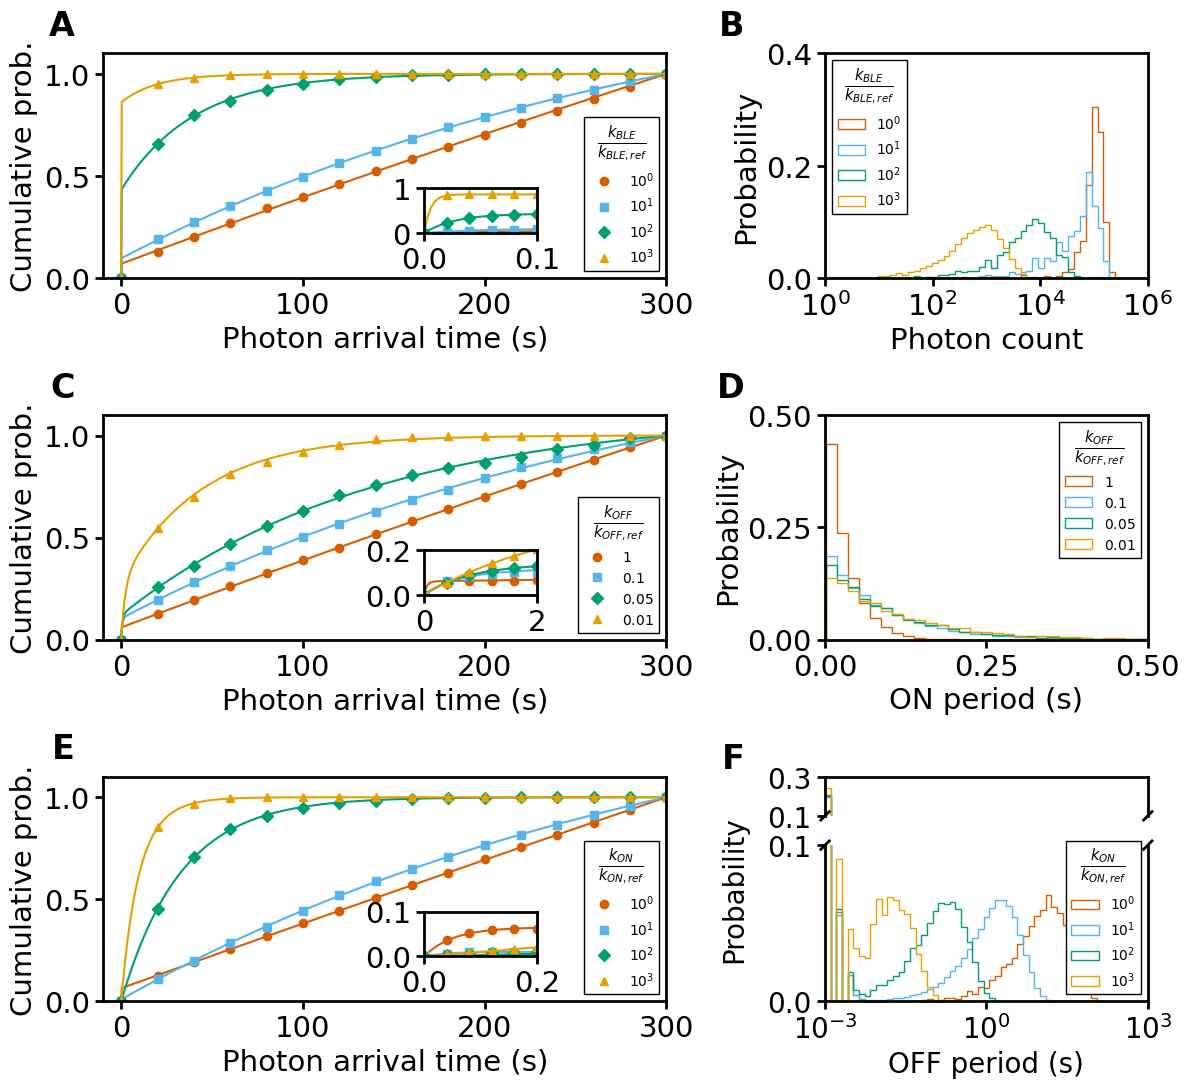

: 

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(
    ax, labels, data, fit, legendtitle, xlim2, ylim2, spacing2, colors=colors
):
    markers = ["o", "s", "D", "^"]
    x = np.linspace(0, 300, 1000)
    spacing1 = 20000
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        legend=True,
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(
            data=[fingerprint.index[::spacing1], fingerprint[::spacing1]],
            label=label,
            color=color,
            marker=marker,
            linestyle="",
            axes=ax,
        )
        fi.universal_figure(
            data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)],
            color=color,
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        legendargs=dict(
            title=legendtitle,
            framealpha=1,
            edgecolor="black",
            fancybox=False,
            title_fontsize=15,
        ),
        **description
    )

    inset = ax.inset_axes([0.57, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    x = np.linspace(0, 300, 100000)
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(
            data=[fingerprint.index[::spacing2], fingerprint[::spacing2]],
            axes=inset,
            label=label,
            color=color,
            marker=marker,
            linestyle="",
        )
        fi.universal_figure(
            data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)],
            axes=inset,
            color=color,
        )
    inset.set_ylabel("")
    inset.set_xlabel("")


import matplotlib.pyplot as plt
from matplotlib import rcParams
from brokenaxes import brokenaxes

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 5)
fig = plt.figure(figsize=(12, 11))
ax1 = fig.add_subplot(gs[0, 0:3])
labels1 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle1 = r"$\frac{k_{BLE}}{k_{BLE,ref}}$"
plot_figure3(
    ax1, labels1, fingerprints_all_A, parameters_all_fit_cdf_A, legendtitle1, 0.1, 1, 20
)
ax2 = fig.add_subplot(gs[0, 3:])
fi.universal_figure(
    type_="hist",
    data=list(reversed(total_photons_A)),
    axes=ax2,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    weights=list(reversed(weights_A)),
    xscale="log",
    bins=log_bins_A,
    ylim=[0, 0.4],
    xlim=[1e0, 1e6],
    ylabel="Probability",
    xlabel="Photon count",
    legend=True,
    legendargs=dict(
        title=legendtitle1,
        framealpha=1,
        edgecolor="black",
        fancybox=False,
        title_fontsize=15,
    ),
)
ax3 = fig.add_subplot(gs[1, 0:3])
labels3 = [r"$1$", r"$0.1$", r"$0.05$", r"$0.01$"]
legendtitle3 = r"$\frac{k_{OFF}}{k_{OFF,ref}}$"
plot_figure3(
    ax3,
    labels3,
    fingerprints_all_B,
    parameters_all_fit_cdf_B,
    legendtitle3,
    2,
    0.2,
    400,
)
ax4 = fig.add_subplot(gs[1, 3:])
fi.universal_figure(
    type_="hist",
    data=list(reversed(ON_periods_B)),
    axes=ax4,
    density=False,
    label=list(reversed(labels3)),
    color=list(reversed(colors)),
    alpha=1,
    weights=list(reversed(weights_B)),
    ylabel="Probability",
    xlabel="ON period (s)",
    histtype="step",
    bins=60,
    legend=True,
    legendargs=dict(
        title=legendtitle3,
        framealpha=1,
        edgecolor="black",
        fancybox=False,
        title_fontsize=15,
    ),
    ylim=[0, 0.5],
    xlim=[0, 0.5],
    xticks=[0, 0.25, 0.5],
    yticks=[0, 0.25, 0.5],
)
ax5 = fig.add_subplot(gs[2, 0:3])
labels5 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle5 = r"$\frac{k_{ON}}{k_{ON,ref}}$"
plot_figure3(
    ax5,
    labels5,
    fingerprints_all_C,
    parameters_all_fit_cdf_C,
    legendtitle5,
    0.2,
    0.1,
    40,
)

bax6 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)), subplot_spec=gs[2, 3:], despine=False, d=0.005,
    hspace=0.3, height_ratios=(1, 4),
)
bax6.hist(
    list(reversed(OFF_periods_C)),
    density=False,
    histtype="step",
    label=list(reversed(labels5)),
    color=list(reversed(colors)),
    alpha=1,
    bins=log_bins_C,
    weights=list(reversed(weights_C)),
)
bax6.set_xscale("log")
bax6.set_ylabel("Probability", fontsize=20, labelpad=55)
bax6.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax6.legend(
    title=legendtitle5,
    framealpha=1,
    edgecolor="black",
    fancybox=False,
    title_fontsize=15,
    loc="lower right",
    #bbox_to_anchor=(0.2, 0, 1, 1),
)
bax6.tick_params(labelsize=20, width=2, length=6)
bax6.set_xlim([1e-3, 1e3])
bax6.set_xticks([1e-3, 1e0, 1e3])
bax6.axs[0].set_yticks([0.1, 0.3])
bax6.axs[1].set_yticks([0, 0.1])

# ax6 = fig.add_subplot(gs[2, 3:])
# fi.universal_figure(
#     type_="hist",
#     data=list(reversed(OFF_periods_C)),
#     axes=ax6,
#     density=False,
#     histtype="step",
#     label=list(reversed(labels5)),
#     color=list(reversed(colors)),
#     alpha=1,
#     xscale="log",
#     bins=log_bins_C,
#     ylabel="Probability",
#     xlabel="OFF period (s)",
#     weights=list(reversed(weights_C)),
#     legend=True,
#     legendargs=dict(
#         title=legendtitle5,
#         framealpha=1,
#         edgecolor="black",
#         fancybox=False,
#         title_fontsize=15,
#     ),
#     ylim=[0, 0.3],
#     xlim=[1e-3, 1e3],
# )
axes = fig.get_axes()
for i, (axis, letter) in enumerate(zip(axes, ["A", "B", "C", "D", "E", "F"])):
    offset = -0.05
    if i % 2 != 0:
        offset = -0.25
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()
for handle in bax6.diag_handles:
    handle.remove()
bax6.draw_diags()
fig.savefig(
    reading_from + r"\single_f_PFA.png", dpi=300, bbox_inches="tight", pad_inches=0.1
)